In [1]:
!pip install mlflow dagshub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 98.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

## Imports

In [7]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

mlflow.set_experiment("DLinear_Training")

BASE = '/kaggle/input/datasets/elenejobava/walmart-features-engineered/'

train_fe = pd.read_parquet(BASE + 'train_features.parquet')
test_fe  = pd.read_parquet(BASE + 'test_features.parquet')

with open(BASE + 'feature_cols.json') as f:
    feature_cols = json.load(f)

train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"]  = pd.to_datetime(test_fe["Date"])

print("Train:", train_fe.shape, train_fe["Date"].min(), "->", train_fe["Date"].max())
print("Test :", test_fe.shape,  test_fe["Date"].min(),  "->", test_fe["Date"].max())
print("Num feature_cols saved:", len(feature_cols))

n_series_train = train_fe.groupby(["Store", "Dept"]).ngroups
n_series_test  = test_fe.groupby(["Store", "Dept"]).ngroups
print("Unique Store-Dept series in train:", n_series_train)
print("Unique Store-Dept series in test :", n_series_test)

HORIZON = test_fe["Date"].nunique()
print("Forecast horizon (# unique weeks in test):", HORIZON)

sample_series = train_fe[(train_fe.Store == 1) & (train_fe.Dept == 1)].sort_values("Date")
gaps = sample_series["Date"].diff().dt.days.dropna().unique()
print("Date gaps (days) in a sample series (should all be 7):", gaps)

print("\nColumns:", list(train_fe.columns))

Device: cuda
Train: (421570, 82) 2010-02-05 00:00:00 -> 2012-10-26 00:00:00
Test : (115064, 82) 2012-11-02 00:00:00 -> 2013-07-26 00:00:00
Num feature_cols saved: 78
Unique Store-Dept series in train: 3331
Unique Store-Dept series in test : 3169
Forecast horizon (# unique weeks in test): 39
Date gaps (days) in a sample series (should all be 7): [7.]

Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'any_markdown', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter', 'Year_norm', 'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos', 'weeks_to_SuperBowl', 'near_SuperBowl', 'weeks_to_LaborDay', 'near_LaborDay', 'weeks_to_Thanksgiving', 'near_Thanksgiving', 'weeks_to_Christmas', 'near_Christmas', 'is_super_bowl', 'is_labor_day', 'is_thanksgiving', 'is_christmas', 'Type_enc', 'Size_log', 'Store_Dept', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6'

In [22]:
import logging
logging.getLogger("mlflow.pytorch").setLevel(logging.ERROR)
logging.getLogger("mlflow.utils.requirements_utils").setLevel(logging.ERROR)

In [16]:
import dagshub

dagshub.init(repo_owner='ejoba22', repo_name='walmart-sales-forecasting', mlflow=True)

mlflow.set_experiment("DLinear_Training")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("DLinear_Training"))

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=7007e2ea-f775-465c-a11f-3271779adb18&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d414d0292076a1347026807f1198ff1c522320f78f2cb4eedbfbbd0bdc742e52




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/walmart-sales-forecasting"

Repository ejoba22/walmart-sales-forecasting initialized!

2026/07/10 18:50:02 INFO mlflow.tracking.fluent: Experiment with name 'DLinear_Training' does not exist. Creating a new experiment.


Tracking URI: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow
Active experiment: <Experiment: artifact_location='mlflow-artifacts:/bfb225c938c44047a06e7f2f2fe2fd44', creation_time=1783709402399, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1783709402399, lifecycle_stage='active', name='DLinear_Training', tags={}, trace_location=None, workspace='default'>


## 2. Series Structure & Window Parameters

Series length stats (weeks per Store-Dept in train):
count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
dtype: float64

Percentiles:
0.01      1.0
0.05     10.0
0.10     48.0
0.25    143.0
0.50    143.0
dtype: float64

Series with any gap > 7 days: 605 out of 3331

Train->Test gap per series (days) - should mostly be 7:
gap_days
7     2920
14      29
21      28
28      19
42      11
Name: count, dtype: int64

Series with < 52 weeks of history: 340 / 3331
Series with < 26 weeks of history: 272 / 3331


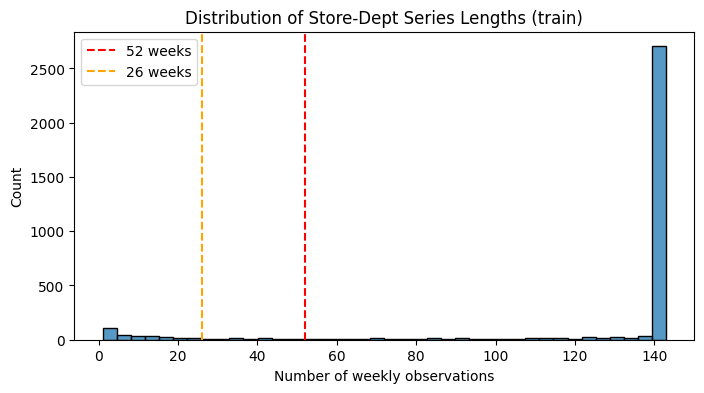


Store-Dept pairs in test with NO train history at all: 11


In [8]:
series_lengths = train_fe.groupby(["Store", "Dept"]).size()
print("Series length stats (weeks per Store-Dept in train):")
print(series_lengths.describe())
print("\nPercentiles:")
print(series_lengths.quantile([0.01, 0.05, 0.10, 0.25, 0.5]))

def max_gap_days(g):
    d = g.sort_values("Date")["Date"].diff().dt.days.dropna()
    return d.max() if len(d) else np.nan

gap_check = train_fe.groupby(["Store", "Dept"]).apply(max_gap_days, include_groups=False)
print("\nSeries with any gap > 7 days:", (gap_check > 7).sum(), "out of", len(gap_check))

train_last_date = train_fe.groupby(["Store", "Dept"])["Date"].max().rename("train_last")
test_first_date  = test_fe.groupby(["Store", "Dept"])["Date"].min().rename("test_first")
merged = pd.concat([train_last_date, test_first_date], axis=1).dropna()
merged["gap_days"] = (merged["test_first"] - merged["train_last"]).dt.days
print("\nTrain->Test gap per series (days) - should mostly be 7:")
print(merged["gap_days"].value_counts().head())

short_series = (series_lengths < 52).sum()
print(f"\nSeries with < 52 weeks of history: {short_series} / {len(series_lengths)}")
short_series_26 = (series_lengths < 26).sum()
print(f"Series with < 26 weeks of history: {short_series_26} / {len(series_lengths)}")

plt.figure(figsize=(8, 4))
sns.histplot(series_lengths, bins=40)
plt.axvline(52, color='red', linestyle='--', label='52 weeks')
plt.axvline(26, color='orange', linestyle='--', label='26 weeks')
plt.title("Distribution of Store-Dept Series Lengths (train)")
plt.xlabel("Number of weekly observations")
plt.legend()
plt.show()

train_pairs = set(zip(train_fe.Store, train_fe.Dept))
test_pairs  = set(zip(test_fe.Store, test_fe.Dept))
new_in_test = test_pairs - train_pairs
print(f"\nStore-Dept pairs in test with NO train history at all: {len(new_in_test)}")

## 3. Reindexing to a Continuous Weekly Grid

Full grid length: 182 weeks

Example gappy series: Store 1, Dept 18, 113 raw rows
Reindexed length: 143
Number of filled-in (previously missing) weeks: 30


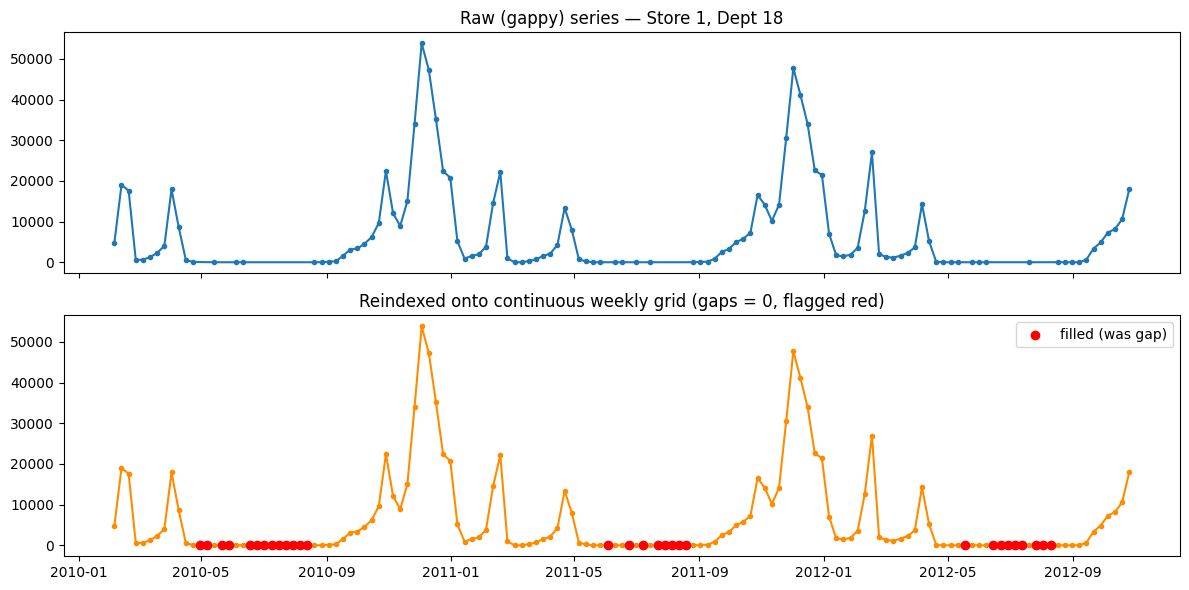


Cold-start Store-Dept pairs (no train history):
[(18, 43), (24, 43), (36, 30), (37, 29), (25, 99), (9, 99), (34, 39), (45, 39), (42, 30), (10, 99), (5, 99)]


In [9]:
full_date_range = pd.date_range(train_fe["Date"].min(), test_fe["Date"].max(), freq="7D")
print("Full grid length:", len(full_date_range), "weeks")

gappy_pair = gap_check[gap_check > 7].index[0]
store_i, dept_i = gappy_pair
example = train_fe[(train_fe.Store == store_i) & (train_fe.Dept == dept_i)].sort_values("Date")
print(f"\nExample gappy series: Store {store_i}, Dept {dept_i}, {len(example)} raw rows")

example_reindexed = (
    example.set_index("Date")["Weekly_Sales"]
    .reindex(full_date_range[full_date_range <= example["Date"].max()])
)
example_reindexed_filled = example_reindexed.fillna(0)
is_active = example_reindexed.notna().astype(int)

print("Reindexed length:", len(example_reindexed))
print("Number of filled-in (previously missing) weeks:", is_active.eq(0).sum())

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(example["Date"], example["Weekly_Sales"], marker='o', markersize=3)
axes[0].set_title(f"Raw (gappy) series — Store {store_i}, Dept {dept_i}")

axes[1].plot(example_reindexed_filled.index, example_reindexed_filled.values, marker='o', markersize=3, color='darkorange')
axes[1].scatter(example_reindexed_filled.index[is_active == 0],
                 example_reindexed_filled.values[is_active == 0],
                 color='red', zorder=5, label='filled (was gap)')
axes[1].set_title("Reindexed onto continuous weekly grid (gaps = 0, flagged red)")
axes[1].legend()
plt.tight_layout()
plt.show()

cold_start_pairs = list(new_in_test)
print("\nCold-start Store-Dept pairs (no train history):")
print(cold_start_pairs)

## 4. Full Panel Construction

In [10]:
full_date_range = pd.date_range(train_fe["Date"].min(), test_fe["Date"].max(), freq="7D")

calendar_cols = [
    'IsHoliday', 'Year', 'Month', 'Week', 'DayOfYear', 'Quarter', 'Year_norm',
    'Week_sin', 'Week_cos', 'Month_sin', 'Month_cos',
    'weeks_to_SuperBowl', 'near_SuperBowl', 'before_SuperBowl',
    'weeks_to_LaborDay', 'near_LaborDay', 'before_LaborDay',
    'weeks_to_Thanksgiving', 'near_Thanksgiving', 'before_Thanksgiving',
    'weeks_to_Christmas', 'near_Christmas', 'before_Christmas',
    'is_super_bowl', 'is_labor_day', 'is_thanksgiving', 'is_christmas'
]
macro_cols = ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
              'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'any_markdown',
              'total_markdown', 'active_markdown_count', 'markdown_x_holiday']
store_cols = ['Type_enc', 'Size_log']

store_covariates = pd.concat([
    train_fe[['Store', 'Date'] + calendar_cols + macro_cols + store_cols],
    test_fe[['Store', 'Date'] + calendar_cols + macro_cols + store_cols]
], axis=0).drop_duplicates(subset=['Store', 'Date']).sort_values(['Store', 'Date'])

print("Store covariate table shape:", store_covariates.shape)
print("Any nulls in covariate table:\n", store_covariates.isnull().sum()[store_covariates.isnull().sum() > 0])

train_pairs_all = set(zip(train_fe.Store, train_fe.Dept))
test_pairs_all  = set(zip(test_fe.Store, test_fe.Dept))
cold_start_pairs = list(test_pairs_all - train_pairs_all)
active_pairs = sorted(train_pairs_all | test_pairs_all - set(cold_start_pairs))

print("Total Store-Dept pairs to model with DLinear:", len(active_pairs))
print("Cold-start pairs set aside for fallback:", len(cold_start_pairs))

target_rows = []
for store_i, dept_i in active_pairs:
    series_dates = full_date_range
    obs = train_fe[(train_fe.Store == store_i) & (train_fe.Dept == dept_i)][['Date', 'Weekly_Sales']]
    obs = obs.set_index('Date').reindex(series_dates)
    obs['Store'] = store_i
    obs['Dept'] = dept_i
    obs['is_active'] = obs['Weekly_Sales'].notna().astype(int)
    obs['Weekly_Sales'] = obs['Weekly_Sales'].fillna(0)
    obs = obs.reset_index().rename(columns={'index': 'Date'})
    target_rows.append(obs)

target_panel = pd.concat(target_rows, axis=0, ignore_index=True)
print("\nTarget panel shape:", target_panel.shape)
print("Expected:", len(active_pairs) * len(full_date_range))

full_panel = target_panel.merge(store_covariates, on=['Store', 'Date'], how='left')
print("\nFull panel shape:", full_panel.shape)
print("Nulls after covariate merge:\n", full_panel.isnull().sum()[full_panel.isnull().sum() > 0])

Store covariate table shape: (8190, 44)
Any nulls in covariate table:
 Series([], dtype: int64)
Total Store-Dept pairs to model with DLinear: 3331
Cold-start pairs set aside for fallback: 11

Target panel shape: (606242, 5)
Expected: 606242

Full panel shape: (606242, 47)
Nulls after covariate merge:
 Series([], dtype: int64)


## 5. Cross-Validation Strategy Rolling-Origin, Time-Based

CV fold (val_start, val_end) week indices on the 182-week grid:
  Fold 0: train < week 104, validate on weeks [104, 117)
  Fold 1: train < week 117, validate on weeks [117, 130)
  Fold 2: train < week 130, validate on weeks [130, 143)


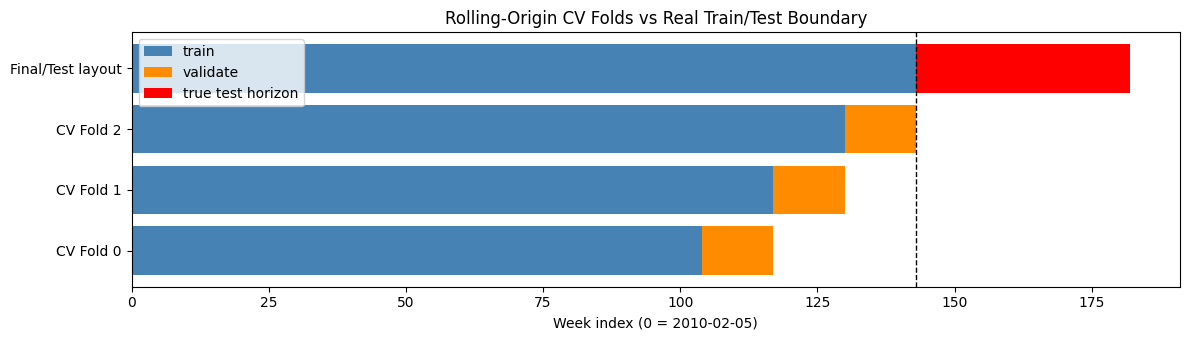


Minimum available lookback at earliest fold's val_start (104 weeks): 104 weeks of history (need 52, rest will be zero-padded+masked)


In [11]:
TRAIN_WEEKS = 143
TEST_HORIZON = 39
LOOKBACK = 52
CV_FOLD_HORIZON = 13
N_CV_FOLDS = 3

fold_cutoffs = []
for i in range(N_CV_FOLDS):
    val_end = TRAIN_WEEKS - (N_CV_FOLDS - 1 - i) * CV_FOLD_HORIZON
    val_start = val_end - CV_FOLD_HORIZON
    fold_cutoffs.append((val_start, val_end))

print("CV fold (val_start, val_end) week indices on the 182-week grid:")
for i, (vs, ve) in enumerate(fold_cutoffs):
    print(f"  Fold {i}: train < week {vs}, validate on weeks [{vs}, {ve})")

fig, ax = plt.subplots(figsize=(12, 3.5))
for i, (vs, ve) in enumerate(fold_cutoffs):
    ax.barh(i, vs, left=0, color='steelblue', label='train' if i == 0 else None)
    ax.barh(i, ve - vs, left=vs, color='darkorange', label='validate' if i == 0 else None)

ax.barh(N_CV_FOLDS, TRAIN_WEEKS, left=0, color='steelblue')
ax.barh(N_CV_FOLDS, TEST_HORIZON, left=TRAIN_WEEKS, color='red', label='true test horizon')

ax.axvline(TRAIN_WEEKS, color='black', linestyle='--', linewidth=1)
ax.set_yticks(list(range(N_CV_FOLDS + 1)))
ax.set_yticklabels([f"CV Fold {i}" for i in range(N_CV_FOLDS)] + ["Final/Test layout"])
ax.set_xlabel("Week index (0 = 2010-02-05)")
ax.set_title("Rolling-Origin CV Folds vs Real Train/Test Boundary")
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"\nMinimum available lookback at earliest fold's val_start ({fold_cutoffs[0][0]} weeks): "
      f"{fold_cutoffs[0][0]} weeks of history (need {LOOKBACK}, rest will be zero-padded+masked)")

## 6. Windowing Dataset

In [12]:
KNOWN_COVARIATE_COLS = calendar_cols

class WalmartWindowDataset(Dataset):
    def __init__(self, panel, active_pairs, cutoff_week, lookback, horizon, covariate_cols):
        self.lookback = lookback
        self.horizon = horizon
        self.covariate_cols = covariate_cols
        self.samples = []

        panel_indexed = panel.set_index(['Store', 'Dept'])

        for store_i, dept_i in active_pairs:
            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            if cutoff_week + horizon > len(series):
                continue

            past = series.iloc[max(0, cutoff_week - lookback):cutoff_week]
            future = series.iloc[cutoff_week:cutoff_week + horizon]

            past_target = past['Weekly_Sales'].values.astype(np.float32)
            past_mask = past['is_active'].values.astype(np.float32)
            pad_len = lookback - len(past_target)
            if pad_len > 0:
                past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])
                past_mask = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_mask])

            future_target = future['Weekly_Sales'].values.astype(np.float32)
            future_mask = future['is_active'].values.astype(np.float32)
            future_holiday_weight = np.where(future['IsHoliday'].values.astype(bool), 5.0, 1.0).astype(np.float32)

            past_cov = past[self.covariate_cols].values.astype(np.float32)
            if pad_len > 0:
                past_cov = np.concatenate([np.zeros((pad_len, past_cov.shape[1]), dtype=np.float32), past_cov], axis=0)
            future_cov = future[self.covariate_cols].values.astype(np.float32)

            self.samples.append({
                'store': store_i,
                'dept': dept_i,
                'past_target': past_target,
                'past_mask': past_mask,
                'past_cov': past_cov,
                'future_cov': future_cov,
                'future_target': future_target,
                'future_mask': future_mask,
                'future_weight': future_holiday_weight,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            'past_target': torch.from_numpy(s['past_target']),
            'past_mask': torch.from_numpy(s['past_mask']),
            'past_cov': torch.from_numpy(s['past_cov']),
            'future_cov': torch.from_numpy(s['future_cov']),
            'future_target': torch.from_numpy(s['future_target']),
            'future_mask': torch.from_numpy(s['future_mask']),
            'future_weight': torch.from_numpy(s['future_weight']),
        }

fold0_val_start, fold0_val_end = fold_cutoffs[0]
train_ds_fold0 = WalmartWindowDataset(full_panel, active_pairs, fold0_val_start, LOOKBACK, CV_FOLD_HORIZON, KNOWN_COVARIATE_COLS)
val_ds_fold0   = WalmartWindowDataset(full_panel, active_pairs, fold0_val_start, LOOKBACK, CV_FOLD_HORIZON, KNOWN_COVARIATE_COLS)

print("Fold 0 dataset size:", len(train_ds_fold0))

sample = train_ds_fold0[0]
for k, v in sample.items():
    print(k, v.shape, v.dtype)

Fold 0 dataset size: 3331
past_target torch.Size([52]) torch.float32
past_mask torch.Size([52]) torch.float32
past_cov torch.Size([52, 27]) torch.float32
future_cov torch.Size([13, 27]) torch.float32
future_target torch.Size([13]) torch.float32
future_mask torch.Size([13]) torch.float32
future_weight torch.Size([13]) torch.float32


## 7. DLinear Model

In [14]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)

    def forward(self, x):
        front = x[:, 0:1, :].repeat(1, self.kernel_size - 1 - (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)).permute(0, 2, 1)
        return x

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAvg(kernel_size)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend

class DLinear(nn.Module):
    def __init__(self, lookback, horizon, n_covariates, kernel_size=13, individual=False):
        super().__init__()
        self.lookback = lookback
        self.horizon = horizon
        self.decomp = SeriesDecomposition(kernel_size)
        self.linear_seasonal = nn.Linear(lookback, horizon)
        self.linear_trend = nn.Linear(lookback, horizon)
        self.covariate_proj = nn.Linear(n_covariates, 1) if n_covariates > 0 else None

    def forward(self, past_target, future_cov=None):
        x = past_target.unsqueeze(-1)
        seasonal, trend = self.decomp(x)
        seasonal = seasonal.squeeze(-1)
        trend = trend.squeeze(-1)

        seasonal_out = self.linear_seasonal(seasonal)
        trend_out = self.linear_trend(trend)
        out = seasonal_out + trend_out

        if self.covariate_proj is not None and future_cov is not None:
            cov_effect = self.covariate_proj(future_cov).squeeze(-1)
            out = out + cov_effect

        return out

model = DLinear(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print("Total trainable parameters:", n_params)

sample_batch = {k: v.unsqueeze(0).to(device) for k, v in sample.items()}
with torch.no_grad():
    out = model(sample_batch['past_target'], sample_batch['future_cov'])
print("Output shape:", out.shape)

DLinear(
  (decomp): SeriesDecomposition(
    (moving_avg): MovingAvg(
      (avg): AvgPool1d(kernel_size=(13,), stride=(1,), padding=(0,))
    )
  )
  (linear_seasonal): Linear(in_features=52, out_features=13, bias=True)
  (linear_trend): Linear(in_features=52, out_features=13, bias=True)
  (covariate_proj): Linear(in_features=27, out_features=1, bias=True)
)
Total trainable parameters: 1406
Output shape: torch.Size([1, 13])


## 8. Multi-Window Training Data + WMAE Loss

In [15]:
class WalmartMultiWindowDataset(Dataset):
    def __init__(self, panel, active_pairs, max_cutoff, lookback, horizon, covariate_cols, stride=4, min_cutoff=None):
        self.samples = []
        panel_indexed = panel.set_index(['Store', 'Dept'])
        min_cutoff = min_cutoff if min_cutoff is not None else lookback + horizon

        for store_i, dept_i in active_pairs:
            series = panel_indexed.loc[(store_i, dept_i)].sort_values('Date').reset_index(drop=True)
            series_len = len(series)
            last_valid_cutoff = min(max_cutoff, series_len - horizon)

            for cutoff in range(min_cutoff, last_valid_cutoff + 1, stride):
                past = series.iloc[max(0, cutoff - lookback):cutoff]
                future = series.iloc[cutoff:cutoff + horizon]
                if len(future) < horizon:
                    continue

                past_target = past['Weekly_Sales'].values.astype(np.float32)
                past_mask = past['is_active'].values.astype(np.float32)
                pad_len = lookback - len(past_target)
                if pad_len > 0:
                    past_target = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_target])
                    past_mask = np.concatenate([np.zeros(pad_len, dtype=np.float32), past_mask])

                past_cov = past[covariate_cols].values.astype(np.float32)
                if pad_len > 0:
                    past_cov = np.concatenate([np.zeros((pad_len, past_cov.shape[1]), dtype=np.float32), past_cov], axis=0)
                future_cov = future[covariate_cols].values.astype(np.float32)

                future_target = future['Weekly_Sales'].values.astype(np.float32)
                future_mask = future['is_active'].values.astype(np.float32)
                future_weight = np.where(future['IsHoliday'].values.astype(bool), 5.0, 1.0).astype(np.float32)

                self.samples.append({
                    'past_target': past_target, 'past_mask': past_mask, 'past_cov': past_cov,
                    'future_cov': future_cov, 'future_target': future_target,
                    'future_mask': future_mask, 'future_weight': future_weight,
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {k: torch.from_numpy(v) for k, v in s.items()}


def wmae_loss(pred, target, mask, weight):
    combined_weight = mask * weight
    numerator = (combined_weight * torch.abs(pred - target)).sum()
    denominator = combined_weight.sum().clamp(min=1e-6)
    return numerator / denominator


fold0_val_start, fold0_val_end = fold_cutoffs[0]
train_ds_fold0 = WalmartMultiWindowDataset(
    full_panel, active_pairs, max_cutoff=fold0_val_start, lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
)
val_ds_fold0 = WalmartWindowDataset(
    full_panel, active_pairs, cutoff_week=fold0_val_start, lookback=LOOKBACK,
    horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
)

print("Fold 0 train samples (sliding windows):", len(train_ds_fold0))
print("Fold 0 val samples (one per series):", len(val_ds_fold0))

Fold 0 train samples (sliding windows): 33310
Fold 0 val samples (one per series): 3331


## 9. Training Loop Fold 0 (Baseline Run)

Epoch 1/30 - train_wmae: 4533.50 - val_wmae: 2562.22
Epoch 2/30 - train_wmae: 2399.90 - val_wmae: 2240.21
Epoch 3/30 - train_wmae: 2053.95 - val_wmae: 2192.00
Epoch 4/30 - train_wmae: 1877.55 - val_wmae: 2151.92
Epoch 5/30 - train_wmae: 1773.65 - val_wmae: 2022.19
Epoch 6/30 - train_wmae: 1707.98 - val_wmae: 1989.59
Epoch 7/30 - train_wmae: 1671.69 - val_wmae: 1953.42
Epoch 8/30 - train_wmae: 1645.79 - val_wmae: 2033.80
Epoch 9/30 - train_wmae: 1626.07 - val_wmae: 2010.62
Epoch 10/30 - train_wmae: 1618.80 - val_wmae: 1925.16
Epoch 11/30 - train_wmae: 1608.36 - val_wmae: 2023.11
Epoch 12/30 - train_wmae: 1603.92 - val_wmae: 1916.61
Epoch 13/30 - train_wmae: 1604.84 - val_wmae: 1988.85
Epoch 14/30 - train_wmae: 1599.37 - val_wmae: 1968.48
Epoch 15/30 - train_wmae: 1595.44 - val_wmae: 1938.02
Epoch 16/30 - train_wmae: 1593.77 - val_wmae: 1938.85
Epoch 17/30 - train_wmae: 1600.87 - val_wmae: 1950.09
Epoch 18/30 - train_wmae: 1594.03 - val_wmae: 1930.40
Epoch 19/30 - train_wmae: 1593.44 - v

2026/07/10 19:02:30 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/10 19:02:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/10 19:02:43 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the loca

🏃 View run DLinear_Fold0_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3/runs/334c9f4ed6674bc88f14a884adbd4da2
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3


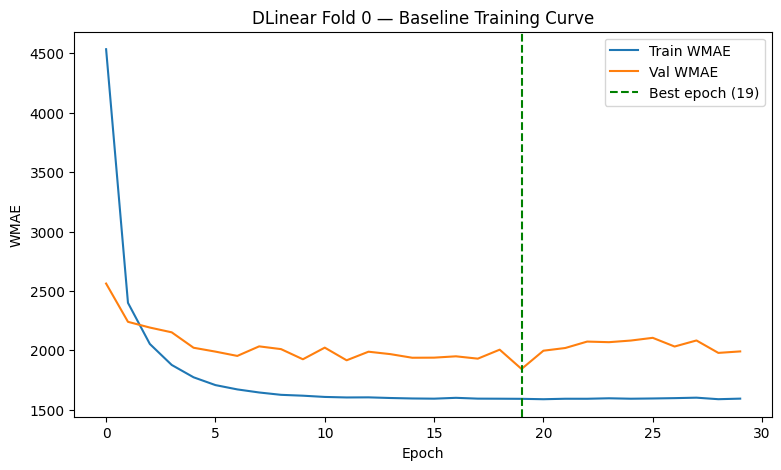

Best val WMAE: 1843.6500625030874 at epoch 19


In [20]:
def collate_fn(batch):
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0].keys()}

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_weight = 0.0, 0.0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            pred = model(batch['past_target'], batch['future_cov'])
            loss = wmae_loss(pred, batch['future_target'], batch['future_mask'], batch['future_weight'])

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_weight = (batch['future_mask'] * batch['future_weight']).sum().item()
            total_loss += loss.item() * batch_weight
            total_weight += batch_weight

    return total_loss / max(total_weight, 1e-6)


BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
KERNEL_SIZE = 13

train_loader = DataLoader(train_ds_fold0, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds_fold0, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = DLinear(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS), kernel_size=KERNEL_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
n_params = sum(p.numel() for p in model.parameters())

example_batch = next(iter(train_loader))
example_past_target = example_batch['past_target'][:1].cpu().numpy()
example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

train_losses, val_losses = [], []
best_val_wmae = float("inf")
best_val_epoch = -1
best_state_dict = None

with mlflow.start_run(run_name="DLinear_Fold0_Baseline"):
    mlflow.set_tags({
        "model_type": "DLinear",
        "fold": "0",
        "run_type": "baseline",
        "device": str(device),
    })

    mlflow.log_params({
        "lookback": LOOKBACK, "horizon": CV_FOLD_HORIZON, "kernel_size": KERNEL_SIZE,
        "batch_size": BATCH_SIZE, "lr": LR, "epochs": EPOCHS, "fold": 0,
        "n_covariates": len(KNOWN_COVARIATE_COLS), "n_params": n_params,
        "individual_weights": False,
    })

    for epoch in range(EPOCHS):
        train_wmae = run_epoch(model, train_loader, optimizer)
        val_wmae = run_epoch(model, val_loader)
        train_losses.append(train_wmae)
        val_losses.append(val_wmae)

        mlflow.log_metric("train_wmae", train_wmae, step=epoch)
        mlflow.log_metric("val_wmae", val_wmae, step=epoch)

        if val_wmae < best_val_wmae:
            best_val_wmae = val_wmae
            best_val_epoch = epoch
            best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1}/{EPOCHS} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

    mlflow.log_metric("best_val_wmae", best_val_wmae)
    mlflow.log_metric("best_val_epoch", best_val_epoch)
    mlflow.log_metric("final_train_wmae", train_losses[-1])
    mlflow.log_metric("final_val_wmae", val_losses[-1])

    model.load_state_dict(best_state_dict)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_losses, label="Train WMAE")
    ax.plot(val_losses, label="Val WMAE")
    ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("WMAE")
    ax.set_title("DLinear Fold 0 — Baseline Training Curve")
    ax.legend()
    mlflow.log_figure(fig, "loss_curve.png")

    mlflow.pytorch.log_model(
        model,
        name="model",
        serialization_format="pickle",
        input_example=(example_past_target, example_future_cov)
    )

plt.show()
print("Best val WMAE:", best_val_wmae, "at epoch", best_val_epoch)

## 10. Refactored Training Function + Full 3-Fold CV

[DLinear_Fold0_Baseline] Epoch 1/30 - train_wmae: 4183.18 - val_wmae: 2829.07
[DLinear_Fold0_Baseline] Epoch 2/30 - train_wmae: 2425.28 - val_wmae: 2393.54
[DLinear_Fold0_Baseline] Epoch 3/30 - train_wmae: 2050.63 - val_wmae: 2095.04
[DLinear_Fold0_Baseline] Epoch 4/30 - train_wmae: 1859.31 - val_wmae: 2169.61
[DLinear_Fold0_Baseline] Epoch 5/30 - train_wmae: 1764.01 - val_wmae: 1960.75
[DLinear_Fold0_Baseline] Epoch 6/30 - train_wmae: 1704.97 - val_wmae: 1970.11
[DLinear_Fold0_Baseline] Epoch 7/30 - train_wmae: 1662.05 - val_wmae: 2048.04
[DLinear_Fold0_Baseline] Epoch 8/30 - train_wmae: 1637.16 - val_wmae: 1931.00
[DLinear_Fold0_Baseline] Epoch 9/30 - train_wmae: 1627.42 - val_wmae: 2010.44
[DLinear_Fold0_Baseline] Epoch 10/30 - train_wmae: 1612.91 - val_wmae: 2095.88
[DLinear_Fold0_Baseline] Epoch 11/30 - train_wmae: 1606.29 - val_wmae: 1950.72
[DLinear_Fold0_Baseline] Epoch 12/30 - train_wmae: 1604.20 - val_wmae: 2064.30
[DLinear_Fold0_Baseline] Epoch 13/30 - train_wmae: 1602.45 - 

2026/07/10 19:06:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/10 19:06:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/10 19:06:56 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the loca

🏃 View run DLinear_Fold0_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3/runs/484fe4e162da4278a582ea356d5192fb
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3
[DLinear_Fold1_Baseline] Epoch 1/30 - train_wmae: 4298.96 - val_wmae: 1991.72
[DLinear_Fold1_Baseline] Epoch 2/30 - train_wmae: 2168.80 - val_wmae: 1649.47
[DLinear_Fold1_Baseline] Epoch 3/30 - train_wmae: 1857.41 - val_wmae: 1544.40
[DLinear_Fold1_Baseline] Epoch 4/30 - train_wmae: 1726.87 - val_wmae: 1486.88
[DLinear_Fold1_Baseline] Epoch 5/30 - train_wmae: 1665.92 - val_wmae: 1497.44
[DLinear_Fold1_Baseline] Epoch 6/30 - train_wmae: 1628.71 - val_wmae: 1445.76
[DLinear_Fold1_Baseline] Epoch 7/30 - train_wmae: 1612.32 - val_wmae: 1460.38
[DLinear_Fold1_Baseline] Epoch 8/30 - train_wmae: 1602.56 - val_wmae: 1540.28
[DLinear_Fold1_Baseline] Epoch 9/30 - train_wmae: 1598.46 - val_wmae: 1477.10
[DLinear_Fold1_Baseline] Epoch 10/30 - train_w

2026/07/10 19:09:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/10 19:09:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/10 19:09:57 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the loca

🏃 View run DLinear_Fold1_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3/runs/7fbb325665924ab987046f9e460241b9
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3
[DLinear_Fold2_Baseline] Epoch 1/30 - train_wmae: 3523.00 - val_wmae: 2201.27
[DLinear_Fold2_Baseline] Epoch 2/30 - train_wmae: 2042.52 - val_wmae: 1763.75
[DLinear_Fold2_Baseline] Epoch 3/30 - train_wmae: 1783.29 - val_wmae: 1680.16
[DLinear_Fold2_Baseline] Epoch 4/30 - train_wmae: 1679.96 - val_wmae: 1608.09
[DLinear_Fold2_Baseline] Epoch 5/30 - train_wmae: 1625.99 - val_wmae: 1570.29
[DLinear_Fold2_Baseline] Epoch 6/30 - train_wmae: 1601.23 - val_wmae: 1559.79
[DLinear_Fold2_Baseline] Epoch 7/30 - train_wmae: 1584.94 - val_wmae: 1543.23
[DLinear_Fold2_Baseline] Epoch 8/30 - train_wmae: 1580.76 - val_wmae: 1521.03
[DLinear_Fold2_Baseline] Epoch 9/30 - train_wmae: 1570.95 - val_wmae: 1515.46
[DLinear_Fold2_Baseline] Epoch 10/30 - train_w

2026/07/10 19:13:04 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/10 19:13:04 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/10 19:13:17 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the loca

🏃 View run DLinear_Fold2_Baseline at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3/runs/bfc69483147c4367bb74275c125e053f
🧪 View experiment at: https://dagshub.com/ejoba22/walmart-sales-forecasting.mlflow/#/experiments/3
   fold  best_val_wmae  best_epoch
0     0    1819.490783          14
1     1    1416.562214          23
2     2    1510.224372          21

Mean CV WMAE: 1582.0924565114135
Std CV WMAE: 210.85925154090208


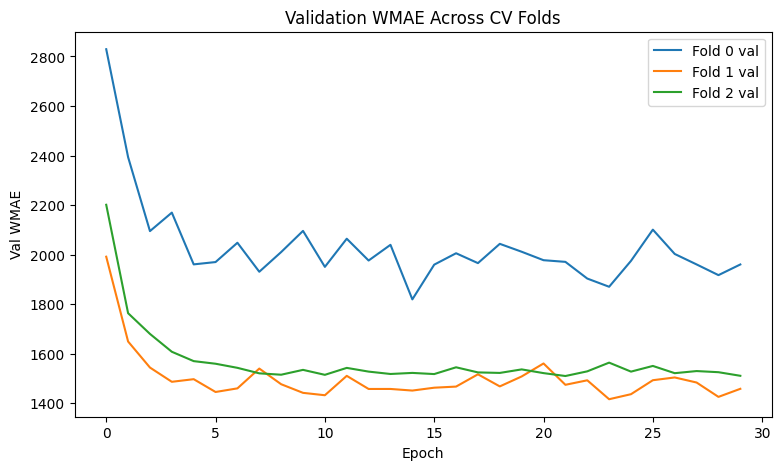

In [21]:
def train_dlinear(train_ds, val_ds, lookback, horizon, n_covariates,
                   kernel_size=13, lr=1e-3, batch_size=256, epochs=30,
                   weight_decay=0.0, individual=False,
                   run_name="DLinear_run", tags=None, log_to_mlflow=True):

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    model = DLinear(lookback=lookback, horizon=horizon, n_covariates=n_covariates, kernel_size=kernel_size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_params = sum(p.numel() for p in model.parameters())

    example_batch = next(iter(train_loader))
    example_past_target = example_batch['past_target'][:1].cpu().numpy()
    example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

    train_losses, val_losses = [], []
    best_val_wmae = float("inf")
    best_val_epoch = -1
    best_state_dict = None

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else None
    if run_ctx:
        run_ctx.__enter__()

    try:
        if log_to_mlflow:
            mlflow.set_tags(tags or {})
            mlflow.log_params({
                "lookback": lookback, "horizon": horizon, "kernel_size": kernel_size,
                "batch_size": batch_size, "lr": lr, "epochs": epochs,
                "weight_decay": weight_decay, "n_covariates": n_covariates,
                "n_params": n_params, "individual_weights": individual,
            })

        for epoch in range(epochs):
            train_wmae = run_epoch(model, train_loader, optimizer)
            val_wmae = run_epoch(model, val_loader)
            train_losses.append(train_wmae)
            val_losses.append(val_wmae)

            if log_to_mlflow:
                mlflow.log_metric("train_wmae", train_wmae, step=epoch)
                mlflow.log_metric("val_wmae", val_wmae, step=epoch)

            if val_wmae < best_val_wmae:
                best_val_wmae = val_wmae
                best_val_epoch = epoch
                best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

            print(f"[{run_name}] Epoch {epoch+1}/{epochs} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

        model.load_state_dict(best_state_dict)

        if log_to_mlflow:
            mlflow.log_metric("best_val_wmae", best_val_wmae)
            mlflow.log_metric("best_val_epoch", best_val_epoch)
            mlflow.log_metric("final_train_wmae", train_losses[-1])
            mlflow.log_metric("final_val_wmae", val_losses[-1])

            fig, ax = plt.subplots(figsize=(9, 5))
            ax.plot(train_losses, label="Train WMAE")
            ax.plot(val_losses, label="Val WMAE")
            ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
            ax.set_xlabel("Epoch")
            ax.set_ylabel("WMAE")
            ax.set_title(f"{run_name} — Training Curve")
            ax.legend()
            mlflow.log_figure(fig, "loss_curve.png")
            plt.close(fig)

            mlflow.pytorch.log_model(
                model, name="model", serialization_format="pickle",
                input_example=(example_past_target, example_future_cov)
            )
    finally:
        if run_ctx:
            run_ctx.__exit__(None, None, None)

    return {
        "model": model, "train_losses": train_losses, "val_losses": val_losses,
        "best_val_wmae": best_val_wmae, "best_val_epoch": best_val_epoch,
    }


fold_results = []

for fold_i, (val_start, val_end) in enumerate(fold_cutoffs):
    train_ds = WalmartMultiWindowDataset(
        full_panel, active_pairs, max_cutoff=val_start, lookback=LOOKBACK,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS, stride=4
    )
    val_ds = WalmartWindowDataset(
        full_panel, active_pairs, cutoff_week=val_start, lookback=LOOKBACK,
        horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
    )

    result = train_dlinear(
        train_ds, val_ds, lookback=LOOKBACK, horizon=CV_FOLD_HORIZON,
        n_covariates=len(KNOWN_COVARIATE_COLS),
        run_name=f"DLinear_Fold{fold_i}_Baseline",
        tags={"model_type": "DLinear", "fold": str(fold_i), "run_type": "baseline"},
    )
    result["fold"] = fold_i
    fold_results.append(result)

cv_summary = pd.DataFrame([{"fold": r["fold"], "best_val_wmae": r["best_val_wmae"], "best_epoch": r["best_val_epoch"]} for r in fold_results])
print(cv_summary)
print("\nMean CV WMAE:", cv_summary["best_val_wmae"].mean())
print("Std CV WMAE:", cv_summary["best_val_wmae"].std())

fig, ax = plt.subplots(figsize=(9, 5))
for r in fold_results:
    ax.plot(r["val_losses"], label=f"Fold {r['fold']} val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val WMAE")
ax.set_title("Validation WMAE Across CV Folds")
ax.legend()
plt.show()

## 11. Refactor: Trainer Takes a Model Instance

In [29]:
def train_model(model, train_ds, val_ds, lr=1e-3, batch_size=256, epochs=30,
                 weight_decay=0.0, run_name="run", tags=None, log_to_mlflow=True):

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    n_params = sum(p.numel() for p in model.parameters())

    example_batch = next(iter(train_loader))
    example_past_target = example_batch['past_target'][:1].cpu().numpy()
    example_future_cov = example_batch['future_cov'][:1].cpu().numpy()

    train_losses, val_losses = [], []
    best_val_wmae = float("inf")
    best_val_epoch = -1
    best_state_dict = None

    run_ctx = mlflow.start_run(run_name=run_name) if log_to_mlflow else None
    if run_ctx:
        run_ctx.__enter__()

    try:
        if log_to_mlflow:
            mlflow.set_tags(tags or {})
            mlflow.log_params({
                "batch_size": batch_size, "lr": lr, "epochs": epochs,
                "weight_decay": weight_decay, "n_params": n_params,
            })

        for epoch in range(epochs):
            train_wmae = run_epoch(model, train_loader, optimizer)
            val_wmae = run_epoch(model, val_loader)
            train_losses.append(train_wmae)
            val_losses.append(val_wmae)

            if log_to_mlflow:
                mlflow.log_metric("train_wmae", train_wmae, step=epoch)
                mlflow.log_metric("val_wmae", val_wmae, step=epoch)

            if val_wmae < best_val_wmae:
                best_val_wmae = val_wmae
                best_val_epoch = epoch
                best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}

            print(f"[{run_name}] Epoch {epoch+1}/{epochs} - train_wmae: {train_wmae:.2f} - val_wmae: {val_wmae:.2f}")

        model.load_state_dict(best_state_dict)

        if log_to_mlflow:
            mlflow.log_metric("best_val_wmae", best_val_wmae)
            mlflow.log_metric("best_val_epoch", best_val_epoch)
            mlflow.log_metric("final_train_wmae", train_losses[-1])
            mlflow.log_metric("final_val_wmae", val_losses[-1])

            fig, ax = plt.subplots(figsize=(9, 5))
            ax.plot(train_losses, label="Train WMAE")
            ax.plot(val_losses, label="Val WMAE")
            ax.axvline(best_val_epoch, color='green', linestyle='--', label=f'Best epoch ({best_val_epoch})')
            ax.set_xlabel("Epoch")
            ax.set_ylabel("WMAE")
            ax.set_title(f"{run_name} — Training Curve")
            ax.legend()
            mlflow.log_figure(fig, "loss_curve.png")
            plt.close(fig)

            mlflow.pytorch.log_model(
                model, name="model", serialization_format="pickle",
                input_example=(example_past_target, example_future_cov)
            )
    finally:
        if run_ctx:
            run_ctx.__exit__(None, None, None)

    return {"model": model, "train_losses": train_losses, "val_losses": val_losses,
            "best_val_wmae": best_val_wmae, "best_val_epoch": best_val_epoch}

## 12. Intentional Overfitting Demo

In [30]:
class OverfitMLP(nn.Module):
    def __init__(self, lookback, horizon, n_covariates, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(lookback, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, horizon),
        )
        self.covariate_proj = nn.Linear(n_covariates, horizon)

    def forward(self, past_target, future_cov=None):
        out = self.net(past_target)
        if future_cov is not None:
            out = out + self.covariate_proj(future_cov.mean(dim=1))
        return out


small_series_subset = active_pairs[:150]

overfit_train_ds = WalmartMultiWindowDataset(
    full_panel, small_series_subset, max_cutoff=fold_cutoffs[0][0],
    lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS,
    stride=52
)
overfit_val_ds = WalmartWindowDataset(
    full_panel, small_series_subset, cutoff_week=fold_cutoffs[0][0],
    lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, covariate_cols=KNOWN_COVARIATE_COLS
)

print("Overfit demo — train samples:", len(overfit_train_ds), "val samples:", len(overfit_val_ds))

overfit_model = OverfitMLP(lookback=LOOKBACK, horizon=CV_FOLD_HORIZON, n_covariates=len(KNOWN_COVARIATE_COLS)).to(device)
n_overfit_params = sum(p.numel() for p in overfit_model.parameters())
print("Overfit model params:", n_overfit_params)

overfit_result = train_model(
    overfit_model, overfit_train_ds, overfit_val_ds,
    lr=3e-3, batch_size=64, epochs=150, weight_decay=0.0,
    run_name="DLinear_Overfit_Demo",
    tags={"model_type": "OverfitMLP", "run_type": "intentional_overfit"},
)

Overfit demo — train samples: 150 val samples: 150
Overfit model params: 559481
[DLinear_Overfit_Demo] Epoch 1/150 - train_wmae: 17448.01 - val_wmae: 8340.18
[DLinear_Overfit_Demo] Epoch 2/150 - train_wmae: 13377.00 - val_wmae: 21952.77
[DLinear_Overfit_Demo] Epoch 3/150 - train_wmae: 19607.52 - val_wmae: 19745.46
[DLinear_Overfit_Demo] Epoch 4/150 - train_wmae: 15463.54 - val_wmae: 8466.11
[DLinear_Overfit_Demo] Epoch 5/150 - train_wmae: 8804.59 - val_wmae: 5003.14
[DLinear_Overfit_Demo] Epoch 6/150 - train_wmae: 5681.00 - val_wmae: 8253.45
[DLinear_Overfit_Demo] Epoch 7/150 - train_wmae: 5227.82 - val_wmae: 4949.80
[DLinear_Overfit_Demo] Epoch 8/150 - train_wmae: 3945.99 - val_wmae: 4025.86
[DLinear_Overfit_Demo] Epoch 9/150 - train_wmae: 2762.89 - val_wmae: 3537.48
[DLinear_Overfit_Demo] Epoch 10/150 - train_wmae: 2668.86 - val_wmae: 3374.19
[DLinear_Overfit_Demo] Epoch 11/150 - train_wmae: 2546.14 - val_wmae: 4523.78
[DLinear_Overfit_Demo] Epoch 12/150 - train_wmae: 2781.16 - val_w